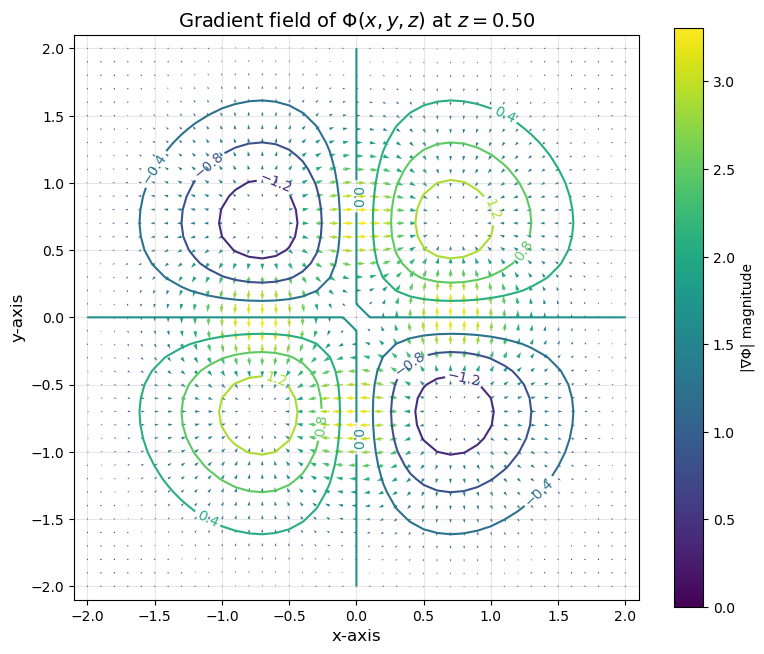

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------
# Domain & sampling 
# --------------------------------------------------
dx = 0.1
axmax = 2.0
n_points = int((2*axmax)/dx) + 1
x = np.linspace(-axmax, axmax, n_points)
y = np.linspace(-axmax, axmax, n_points)
z = np.linspace(-axmax, axmax, n_points)

# Grid of sample points
X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

# --------------------------------------------------
# Scalar field: Phi(x,y,z) = 10*x*y*exp(-(x^2+y^2+z^2))
# --------------------------------------------------
Phi = 10.0 * X * Y * np.exp(-(X**2 + Y**2 + Z**2))

# Gradient (numerical)
dy, dx, dz = (y[1]-y[0]), (x[1]-x[0]), (z[1]-z[0])
dPhi_dy, dPhi_dx, dPhi_dz = np.gradient(Phi, dy, dx, dz)

# --------------------------------------------------
# Slice selection
# --------------------------------------------------
m = n_points//2 + 5     # slice index
m = min(m, n_points-1)  # safety clamp
z_m = z[m]

# --------------------------------------------------
# Plot: contour + gradient vectors
# --------------------------------------------------
plt.figure(figsize=(8, 7))

# Contour of Phi at z = z_m
CS = plt.contour(X[:, :, m], Y[:, :, m], Phi[:, :, m], cmap="viridis")
plt.clabel(CS, inline=True, fontsize=10)

# Gradient vectors in the xy-plane
U = dPhi_dx[:, :, m]
V = dPhi_dy[:, :, m]
magnitude = np.hypot(U, V)

q = plt.quiver(
    X[:, :, m], Y[:, :, m],
    U, V,
    magnitude,                # color by magnitude
    cmap="viridis",
    angles='xy', scale_units='xy', scale=40, pivot='tail'
)

plt.colorbar(q, label="|∇Φ| magnitude", shrink=0.9)

# Labels & title
plt.xlabel('x-axis', fontsize=12)
plt.ylabel('y-axis', fontsize=12)
plt.title(rf'Gradient field of $\Phi(x,y,z)$ at $z={z_m:.2f}$', fontsize=14)

# Grid, aspect ratio, limits
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(1.05*x.min(), 1.05*x.max())
plt.ylim(1.05*y.min(), 1.05*y.max())
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


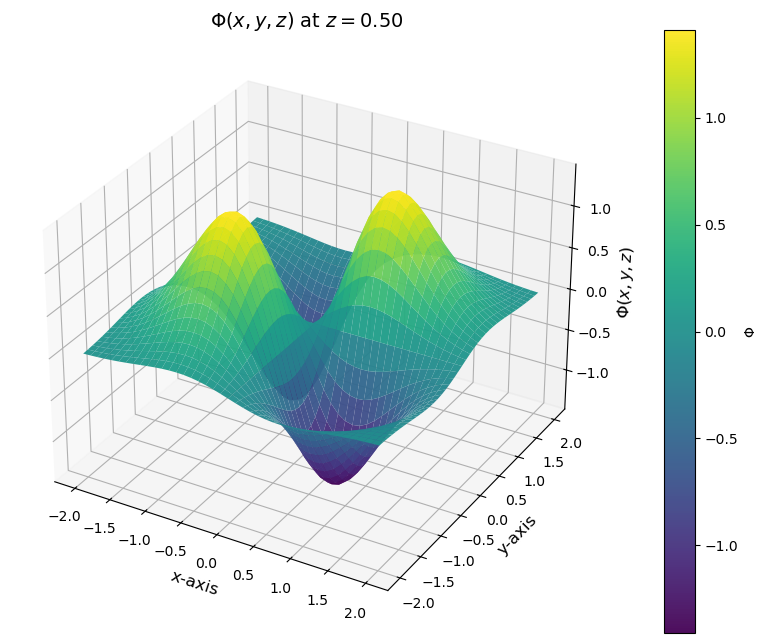

In [11]:
# --------------------------------------------------
# 3D surface of Phi at the same z-slice
# --------------------------------------------------
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X[:, :, m], Y[:, :, m], Phi[:, :, m],
    cmap="viridis",
    linewidth=0, antialiased=True, alpha=0.95
)

ax.set_xlabel('x-axis', fontsize=12)
ax.set_ylabel('y-axis', fontsize=12)
ax.set_zlabel(r'$\Phi(x,y,z)$', fontsize=12)
ax.set_title(rf'$\Phi(x,y,z)$ at $z={z_m:.2f}$', fontsize=14)

# Colorbar for Phi values
fig.colorbar(surf, shrink=0.9, pad=0.08, label=r'$\Phi$')

plt.tight_layout()
plt.show()